<a href="https://colab.research.google.com/github/el-danieel/desafio-dio-calculo-de-metricas-de-avaliacao-de-aprendizado/blob/main/Desafio_de_projeto_C%C3%A1lculo_de_M%C3%A9tricas_de_Avalia%C3%A7%C3%A3o_de_Aprendizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Matriz de confusão
[[13  0  0]
 [ 0 10  6]
 [ 0  0  9]]


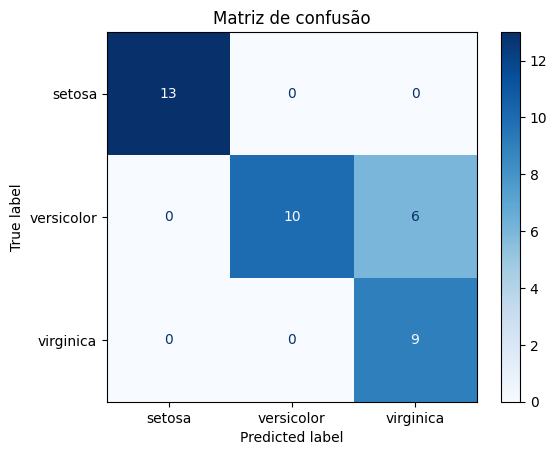

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, svm
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# import some data to play with
iris = datasets.load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

# Split the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Run classifier, using a model that is too regularized (C too low) to see
# the impact on the results
classifier = svm.SVC(kernel="linear", C=0.01).fit(X_train, y_train)

np.set_printoptions(precision=2)

disp = ConfusionMatrixDisplay.from_estimator(
  classifier,
  X_test,
  y_test,
  display_labels=class_names,
  cmap=plt.cm.Blues
)
disp.ax_.set_title("Matriz de confusão")
cm = disp.confusion_matrix
print("Matriz de confusão")
print(cm)

plt.show()

In [ ]:
VP = []
FP = []
FN = []
VN = []

VP.append(cm[0][0])
VP.append(cm[1][1])
VP.append(cm[2][2])

FP.append(cm[0][1] + cm[0][2])
FP.append(cm[1][0] + cm[1][2])
FP.append(cm[2][0] + cm[2][1])

FN.append(cm[1][0] + cm[2][0])
FN.append(cm[0][1] + cm[2][1])
FN.append(cm[0][2] + cm[1][2])

VN.append(VP[1] + VP[2] + cm[2][1] + cm[1][2])
VN.append(VP[0] + VP[2] + cm[0][2] + cm[2][1])
VN.append(VP[0] + VP[1] + cm[0][1] + cm[1][0])

print(VP, FP, FN, VN)

[13, 10, 9] [0, 6, 0] [0, 0, 6] [25, 22, 23]


In [ ]:
sensibilidade = []
especificidade = []
acuracia = []
precisao = []
f_score = []

for i in range(0, 3):
  sensibilidade.append(VP[i] / (VP[i] + FN[i]))
  especificidade.append(VN[i] / (VN[i] + FP[i]))
  acuracia.append((VP[i] + VN[i]) / (VP[i] + VN[i] + FP[i] + FN[i]))
  precisao.append(VP[i] / (VP[i] + FP[i]))
  f_score.append(2 * (precisao[i] * sensibilidade[i]) / (precisao[i] + sensibilidade[i]))

In [ ]:
for i in range(0, 3):
  print(f"Classe {class_names[i]}:")
  print(f"Sensibilidade: {sensibilidade[i]}")
  print(f"Especificidade: {especificidade[i]}")
  print(f"Acurácia: {acuracia[i]}")
  print(f"Precisão: {precisao[i]}")
  print(f"F-Score: {f_score[i]}\n")

Classe setosa:
Sensibilidade: 1.0
Especificidade: 1.0
Acurácia: 1.0
Precisão: 1.0
F-Score: 1.0

Classe versicolor:
Sensibilidade: 1.0
Especificidade: 0.7857142857142857
Acurácia: 0.8421052631578947
Precisão: 0.625
F-Score: 0.7692307692307693

Classe virginica:
Sensibilidade: 0.6
Especificidade: 1.0
Acurácia: 0.8421052631578947
Precisão: 1.0
F-Score: 0.7499999999999999

